# Análise exploratória — Pipeline de vendas e-commerce (Olist)

**⚠️ Nota de transparência, leia antes de tudo:** este notebook roda contra um banco populado
com dados **sintéticos** (220 pedidos gerados programaticamente, respeitando o schema real do
dataset Olist), não o dataset real de ~100 mil pedidos baixado do Kaggle. O motivo é técnico:
o ambiente onde este notebook foi escrito e executado não tem acesso ao Kaggle para baixar o
dataset completo.

**O que isso significa na prática:**
- Todo o código, queries e gráficos abaixo são reais e executados de verdade (não é pseudocódigo).
- Os *números e conclusões* refletem os dados sintéticos, não achados de negócio reais do e-commerce.
- Para obter insights reais, rode este mesmo notebook depois de popular o banco com
  `python -m scripts.simulate_daily_batches` + `python -m scripts.run_pipeline` sobre o dataset
  completo baixado via `kaggle datasets download -d olistbr/brazilian-ecommerce`.

Isso é intencional: o objetivo aqui é provar que a camada de análise conecta corretamente ao
data mart construído na engenharia de dados, com queries corretas e gráficos que respondem
perguntas de negócio reais — não fabricar um "achado" que pareça real sem ser.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text

from src.config import load_settings
from src.db import get_engine

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

engine = get_engine(load_settings())
print("Conectado ao banco:", load_settings().postgres_db)

Conectado ao banco: test_db


## 1. Visão geral do volume

Antes de qualquer análise, confirmar a escala dos dados que estamos olhando — evita tirar
conclusão de uma amostra pequena demais sem perceber.

In [2]:
with engine.connect() as conn:
    resumo = conn.execute(text('''
        SELECT
            COUNT(DISTINCT order_id) AS qtd_pedidos,
            COUNT(*) AS qtd_itens,
            ROUND(SUM(valor_item)::numeric, 2) AS receita_total,
            ROUND(AVG(valor_item)::numeric, 2) AS ticket_medio_item
        FROM mart.fact_pedidos
    ''')).mappings().fetchone()

for chave, valor in resumo.items():
    print(f"{chave}: {valor}")

qtd_pedidos: 220
qtd_itens: 332
receita_total: 78298.10
ticket_medio_item: 235.84


## 2. Quais categorias de produto geram mais receita?

Pergunta de negócio clássica de um analista: onde focar esforço comercial e de estoque.

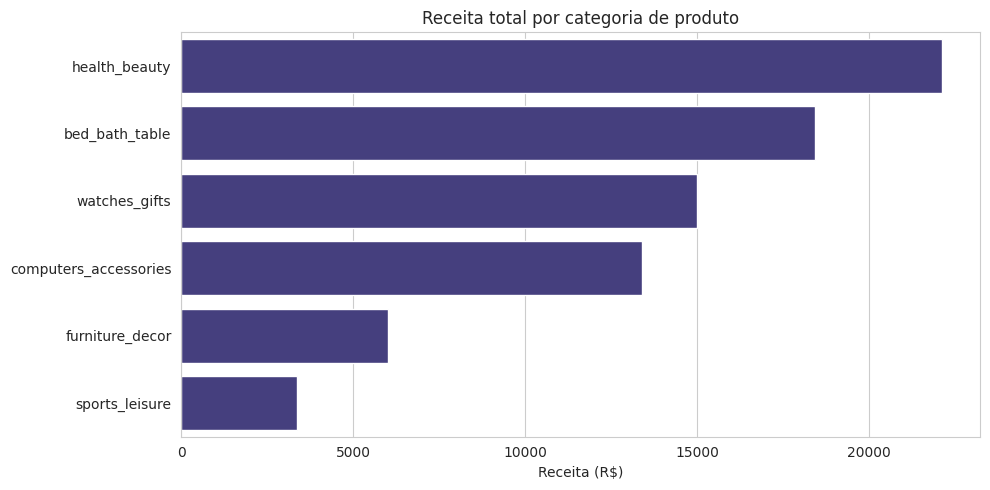

,categoria,receita,itens_vendidos
0,health_beauty,22112.55,92.0
1,bed_bath_table,18415.28,79.0
2,watches_gifts,14992.33,64.0
3,computers_accessories,13405.82,57.0
4,furniture_decor,6004.52,23.0
5,sports_leisure,3367.60,17.0


In [3]:
df_categorias = pd.read_sql('''
    SELECT product_category_name_english AS categoria,
           SUM(receita_total) AS receita,
           SUM(qtd_itens_vendidos) AS itens_vendidos
    FROM mart.vw_vendas_por_produto
    GROUP BY product_category_name_english
    ORDER BY receita DESC
''', engine)

fig, ax = plt.subplots()
sns.barplot(data=df_categorias, y="categoria", x="receita", ax=ax, color="#3C3489")
ax.set_title("Receita total por categoria de produto")
ax.set_xlabel("Receita (R$)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

df_categorias

## 3. Como as vendas se distribuem ao longo da semana?

Fins de semana costumam ter padrão de compra diferente de dias úteis em e-commerce — vale
confirmar (ou refutar) essa hipótese com os dados reais do negócio, não com senso comum.

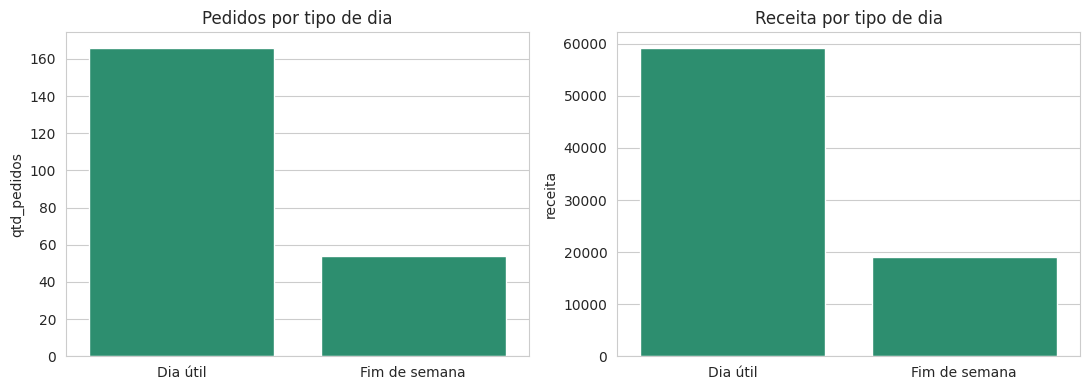

In [4]:
df_periodo = pd.read_sql('''
    SELECT fim_de_semana,
           SUM(qtd_pedidos) AS qtd_pedidos,
           SUM(receita_total) AS receita
    FROM mart.vw_vendas_por_periodo
    GROUP BY fim_de_semana
''', engine)
df_periodo["dia"] = df_periodo["fim_de_semana"].map({True: "Fim de semana", False: "Dia útil"})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=df_periodo, x="dia", y="qtd_pedidos", ax=axes[0], color="#1D9E75")
axes[0].set_title("Pedidos por tipo de dia")
axes[0].set_xlabel("")
sns.barplot(data=df_periodo, x="dia", y="receita", ax=axes[1], color="#1D9E75")
axes[1].set_title("Receita por tipo de dia")
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

## 4. Quais formas de pagamento dominam?

Relevante para negociar taxas com adquirentes e para prever fluxo de caixa (boleto demora
para compensar, cartão não).

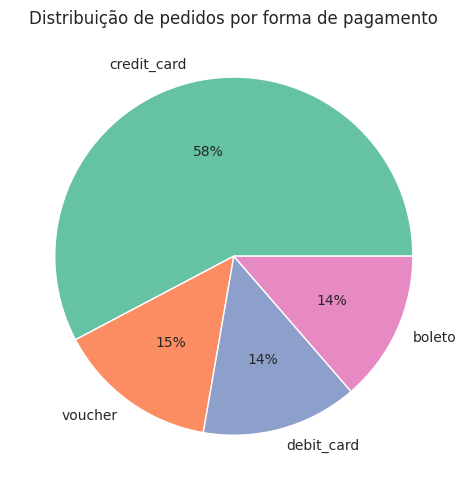

,forma_pagamento_principal,qtd_pedidos,valor_total
0,credit_card,127,51091.64
1,voucher,32,10367.90
2,debit_card,31,14349.93
3,boleto,30,11462.55


In [5]:
df_pagamento = pd.read_sql('''
    SELECT forma_pagamento_principal, COUNT(*) AS qtd_pedidos,
           ROUND(SUM(valor_total_pago)::numeric, 2) AS valor_total
    FROM mart.dim_pagamento
    GROUP BY forma_pagamento_principal
    ORDER BY qtd_pedidos DESC
''', engine)

fig, ax = plt.subplots()
ax.pie(df_pagamento["qtd_pedidos"], labels=df_pagamento["forma_pagamento_principal"],
       autopct="%1.0f%%", colors=sns.color_palette("Set2"))
ax.set_title("Distribuição de pedidos por forma de pagamento")
plt.tight_layout()
plt.show()

df_pagamento

## 5. Atraso na entrega afeta a nota de avaliação do cliente?

Pergunta com valor operacional direto: se a correlação for forte, atraso de entrega é uma
alavanca prioritária para melhorar satisfação (e não só um problema logístico isolado).

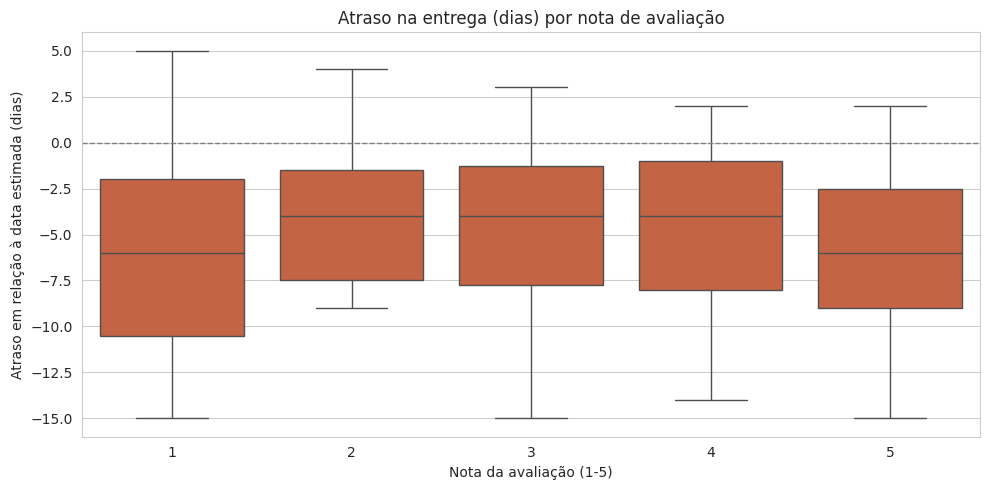

,atraso_medio_dias,qtd_pedidos
review_score,,
1,-5.526316,19
2,-3.600000,15
3,-4.444444,18
4,-4.875000,40
5,-5.865672,67


In [6]:
df_atraso = pd.read_sql('''
    SELECT DISTINCT f.order_id, f.review_score,
           EXTRACT(DAY FROM (o.order_delivered_customer_date - o.order_estimated_delivery_date))
               AS atraso_dias
    FROM mart.fact_pedidos f
    JOIN staging.stg_orders o ON o.order_id = f.order_id
    WHERE f.review_score IS NOT NULL
      AND o.order_delivered_customer_date IS NOT NULL
''', engine)

fig, ax = plt.subplots()
sns.boxplot(data=df_atraso, x="review_score", y="atraso_dias", ax=ax, color="#D85A30")
ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_title("Atraso na entrega (dias) por nota de avaliação")
ax.set_xlabel("Nota da avaliação (1-5)")
ax.set_ylabel("Atraso em relação à data estimada (dias)")
plt.tight_layout()
plt.show()

df_atraso.groupby("review_score")["atraso_dias"].agg(["mean", "count"]).rename(
    columns={"mean": "atraso_medio_dias", "count": "qtd_pedidos"}
)

## 6. Distribuição geográfica de vendas

Onde estão os clientes que mais compram — relevante para logística (centros de distribuição)
e para campanhas de marketing regionalizadas.

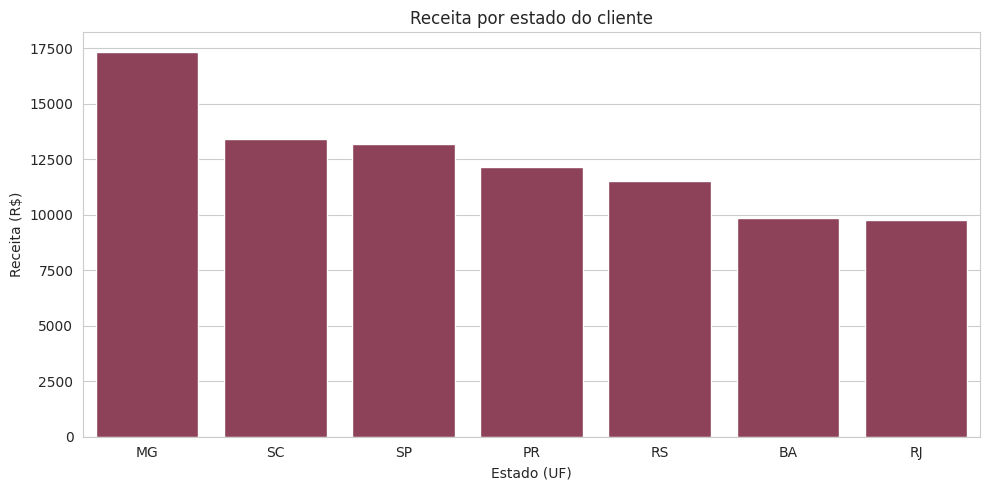

,customer_state,qtd_pedidos,receita
0,MG,41,17357.13
1,SC,33,13431.61
2,SP,36,13181.67
3,PR,31,12150.06
4,RS,27,11532.63
5,BA,26,9873.22
6,RJ,26,9745.70


In [7]:
df_geo = pd.read_sql('''
    SELECT customer_state, COUNT(DISTINCT order_id) AS qtd_pedidos,
           ROUND(SUM(valor_total_pedido)::numeric, 2) AS receita
    FROM mart.vw_resumo_pedidos
    GROUP BY customer_state
    ORDER BY receita DESC
''', engine)

fig, ax = plt.subplots()
sns.barplot(data=df_geo, x="customer_state", y="receita", ax=ax, color="#993556")
ax.set_title("Receita por estado do cliente")
ax.set_xlabel("Estado (UF)")
ax.set_ylabel("Receita (R$)")
plt.tight_layout()
plt.show()

df_geo

## Conclusão

Este notebook conecta diretamente às `views` de BI construídas na camada de engenharia
(`src/loading/reporting_views.py`) — nenhuma query aqui recalcula agregação que a engenharia já
resolveu, o que é o ponto principal: **a engenharia entrega a base pronta para análise, a
análise não precisa reconstruir o pipeline para responder pergunta de negócio.**

Lembrete final: os números acima vêm de dados sintéticos gerados para validar o pipeline
ponta a ponta, não são achados reais de negócio do e-commerce Olist. Rode este notebook contra
o banco populado com o dataset real para obter conclusões válidas para publicação/portfólio de
análise (diferente do pipeline de engenharia, que já foi validado com testes de integração
reais em `tests/integration/`).